# Ultraheavy dark matter with a finite-range mediator

The [momentum-kick tutorial](TUTORIAL_UHDM.md) used a *massless* mediator, where the
rate factorizes as $(\alpha_n N_n)^2 \times$ a fixed spectrum shape and
`OptimumIntervalTable.upper_limit` applies directly. For a mediator of **finite range**
$\lambda$ that factorization breaks: the momentum transfer from a flyby at impact
parameter $b$ is

$$q(b) \simeq \frac{2\,\alpha}{\lambda v}\, G_2\!\left(\tfrac{R_\text{eff}}{\lambda}\right) K_1\!\left(\tfrac{b}{\lambda}\right),
\qquad \alpha = \alpha_n N_n,$$

so the kinematic endpoint and the whole shape of $dR/dq$ move with the coupling
$\alpha_n$ — the parameter we are limiting. This notebook shows the right pattern for
that case: **scan the coupling**, and at each candidate $\alpha_n$ evaluate the
optimum-interval extremeness with the package *primitives* (`generate`,
`optimum_interval_statistic`, `extremeness_of_opt_itv_stat`), using that coupling's own
spectrum. The package stays "events + shape in, statistics out"; all physics lives here.

Inputs: the standard-halo-model velocity distribution, classical scattering of a
pointlike heavy particle off a finite-size levitated magnet through a Yukawa
potential, and a toy set of candidate kicks. **All experimental parameters are
illustrative fiducials** (a levitated-magnet impulse search of the kind in
[arXiv:2409.03814](https://arxiv.org/abs/2409.03814)); substitute your own.


In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import IntegrationWarning, quad
from scipy.interpolate import interp1d
from scipy.special import erf, kn

from optimum_interval import (
    OptimumIntervalTable,
    poisson_upper_limit,
    spectrum_cdf_from_samples,
)

# benign roundoff warning in the K1 quadrature
warnings.filterwarnings("ignore", category=IntegrationWarning)

RNG_SEED = 20260702

# --- fiducial constants (natural units: GeV, c = 1) ---
C_M_S = 299792458.0
V0 = 220e3 / C_M_S  # halo velocity dispersion parameter
VESC = 544e3 / C_M_S  # galactic escape velocity
RHO_DM = 2.3e-42  # 0.3 GeV/cm^3 in GeV^4
GEV_PER_S = 1.519e24  # 1 GeV of rate = 1.519e24 s^-1

M_MAG_KG = 0.42e-6  # levitated magnet mass
N_NEUTRONS = M_MAG_KG / 1.67e-27  # fiducial: count all nucleons
R_EFF = 0.26e-3  # magnet effective radius [m]
LAMB = 3e-3  # mediator range lambda [m]
Q_TH = 8.4e3  # momentum threshold [GeV]
T_OBS_S = 3600 * 24 * 14.0  # two weeks of livetime
CONFIDENCE = 0.95


def m_to_per_gev(x):
    """meters -> GeV^-1"""
    return 5.0679e6 * x * 1e9


LAMB_GEV = m_to_per_gev(LAMB)
XI = R_EFF / LAMB  # sensor size in units of the mediator range
print(f"N_n = {N_NEUTRONS:.2e}, xi = R_eff/lambda = {XI:.3f}")

N_n = 2.51e+20, xi = R_eff/lambda = 0.087


## Velocity distribution: the standard halo model

A truncated Maxwellian with dispersion $\sigma_v = v_0/\sqrt{2}$, normalized on
$[0, v_\text{esc}]$:

$$f(v) = \frac{4\pi v^2}{(2\pi\sigma_v^2)^{3/2}\,N_\text{esc}}\;
e^{-v^2/2\sigma_v^2}\;\Theta(v_\text{esc}-v).$$


In [2]:
SIG_V = V0 / np.sqrt(2)
N_ESC = erf(VESC / V0) - np.sqrt(2 / np.pi) * (VESC / SIG_V) * np.exp(
    -(VESC**2) / (2 * SIG_V**2)
)


def f_halo(v):
    """SHM speed distribution, normalized so its integral over [0, v_esc] is 1."""
    return (
        4
        * np.pi
        * v**2
        / ((2 * np.pi * SIG_V**2) ** 1.5 * N_ESC)
        * np.exp(-(v**2) / (2 * SIG_V**2))
        * np.heaviside(VESC - v, 0.0)
    )


v_check = np.linspace(0, VESC, 4000)
print(f"normalization check: integral = {np.trapezoid(f_halo(v_check), v_check):.6f}")

normalization check: integral = 0.999991


## Cross section: finite-range Yukawa, finite-size sensor

The sensor's finite size enters through the shape factor
$G_2(x) = 3(x\cosh x - \sinh x)/x^3$, and the impulse is measured as a *projection*
on the sensitive axis. In the dimensionless variable
$\tilde q \equiv q\,\lambda v / (2\alpha G_2)$ the projected differential cross
section is

$$\frac{d\sigma}{d\tilde q} = \int_0^{\cosh^{-1}(K_1(\xi)/\tilde q)}
\frac{\beta(\kappa)}{|K_1'(\beta(\kappa))|}\,dt,
\qquad \kappa = \tilde q \cosh t,$$

where $\beta(\kappa)$ inverts $K_1$. The support ends at
$\tilde q_\text{max} = K_1(\xi)$: a finite-range mediator **caps the momentum
transfer**, which is what will create a hard sensitivity floor in the coupling.
We tabulate $d\sigma/d\tilde q$ once and interpolate.


In [3]:
def shape_factor(x):
    return 3.0 * (x * np.cosh(x) - np.sinh(x)) / x**3


F_XI = shape_factor(XI)
Q_TILDE_MAX = kn(1, XI)

# Invert K1 on a grid (K1 is monotone decreasing; range chosen to avoid underflow).
_beta_grid = np.geomspace(1e-4, 30.0, 6000)
_k1_inv = interp1d(kn(1, _beta_grid), _beta_grid)
K1_LO, K1_HI = kn(1, 30.0), kn(1, 1e-4)


def k1_inverse(k):
    k = np.asarray(k, float)
    return np.where(k > 100.0, 1.0 / k, _k1_inv(np.clip(k, K1_LO, K1_HI)))


def dsigma_dq_tilde(q_tilde):
    """Dimensionless projected differential cross section."""
    if q_tilde >= Q_TILDE_MAX:
        return 0.0
    t_max = np.arccosh(Q_TILDE_MAX / q_tilde)

    def integrand(t):
        beta = k1_inverse(q_tilde * np.cosh(t))
        return beta / np.abs(0.5 * (kn(0, beta) + kn(2, beta)))

    return quad(integrand, 0, t_max, limit=200)[0]


_qt_grid = np.geomspace(1e-10, Q_TILDE_MAX * (1 - 1e-9), 300)
_ds_interp = interp1d(
    _qt_grid, [dsigma_dq_tilde(qt) for qt in _qt_grid], bounds_error=False, fill_value=0.0
)


def dsigma_dq(q, alpha, v):
    """Physical dsigma/dq in GeV^-3 (q in GeV, v in units of c). Vectorized in v."""
    q_tilde = q * LAMB_GEV * v / (2 * alpha * F_XI)
    return _ds_interp(q_tilde) * LAMB_GEV**3 * v / (alpha * F_XI)


print(f"G2(xi) = {F_XI:.5f},  q_tilde_max = K1(xi) = {Q_TILDE_MAX:.3f}")

G2(xi) = 1.00075,  q_tilde_max = K1(xi) = 11.406


## Differential rate

$$\frac{dR}{dq} = n_\text{DM} \int_{v_\text{min}(q)}^{v_\text{esc}}
f(v)\, v\, \frac{d\sigma}{dq}(q, v)\, dv,
\qquad v_\text{min} = q/m_\text{DM},\quad n_\text{DM} = \rho_\text{DM}/m_\text{DM}.$$

Note the finite-range peculiarity visible below: $q(b)\propto 1/v$, so *slow*
particles deliver the largest kicks, and the spectrum endpoint is set by the
interplay of $\tilde q < K_1(\xi)$ with $v \ge v_\text{min}$.


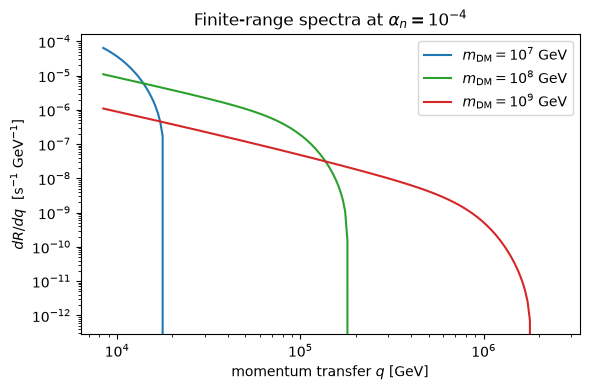

In [4]:
def drdq(qs, alpha_n, m_dm):
    """dR/dq in s^-1 GeV^-1 on the array qs."""
    alpha = alpha_n * N_NEUTRONS
    n_dm = RHO_DM / m_dm
    out = np.zeros_like(qs)
    for i, q in enumerate(qs):
        v_min = q / m_dm
        if v_min >= VESC:
            continue
        vs = np.geomspace(max(v_min, 1e-6), VESC, 300)
        out[i] = np.trapezoid(n_dm * f_halo(vs) * vs * dsigma_dq(q, alpha, vs), vs)
    return np.maximum(out, 0.0) * GEV_PER_S


qs_plot = np.geomspace(Q_TH, 300 * Q_TH, 200)
fig, ax = plt.subplots(figsize=(6, 4))
for m_dm, color in [(1e7, "#1f77b4"), (1e8, "#2ca02c"), (1e9, "#d62728")]:
    ax.loglog(
        qs_plot,
        drdq(qs_plot, 1e-4, m_dm),
        color=color,
        label=rf"$m_{{\rm DM}} = 10^{{{int(np.log10(m_dm))}}}$ GeV",
    )
ax.set_xlabel(r"momentum transfer $q$ [GeV]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ GeV$^{-1}$]")
ax.set_title(r"Finite-range spectra at $\alpha_n = 10^{-4}$")
ax.legend()
fig.tight_layout()

## Candidates and the coupling-grid limit

Toy dataset: four transients just above threshold plus one outlier (as in the
massless-mediator example). Because the spectrum shape depends on $\alpha_n$, we
cannot solve for $\mu$ once and convert. Instead, for each mass we scan
$\alpha_n$, and at each grid point:

1. build that coupling's spectrum $dR/dq$, its support window, and
   $\mu(\alpha_n) = T_\text{obs}\int dR/dq\,dq$;
2. keep only candidates inside the window (kicks beyond the endpoint cannot be
   signal at this coupling);
3. evaluate the optimum-interval **extremeness** of the data at
   $(\mu, \text{shape})$ with the package primitives;
4. interpolate where the extremeness crosses the confidence level.

Two shortcuts keep it fast: $\mu$ is rounded to a 2%-spaced log grid so the
Monte-Carlo calibration tables are shared across masses and couplings, and
$\mu > 40$ with $\le 5$ observed events is excluded outright (extremeness
indistinguishable from 1).


In [5]:
KICKS = np.array([8600.0, 8900.0, 9300.0, 9800.0, 30000.0])  # GeV
N_MC = 2000
table = OptimumIntervalTable(rng=np.random.default_rng(RNG_SEED))


def round_log(x, dex=0.02):
    return 10 ** (np.round(np.log10(x) / dex) * dex)


def spectrum_at(alpha_n, m_dm, n_q=160):
    """Return (mu, cdf, q_lo, q_hi) for this coupling and mass, or None if no support."""
    qs = np.geomspace(Q_TH, 1000 * Q_TH, n_q)
    rate = drdq(qs, alpha_n, m_dm)
    if not np.any(rate > 0):
        return None
    hi = np.max(np.where(rate > 0)[0])
    qs, rate = qs[: hi + 1], rate[: hi + 1]
    mu = float(np.trapezoid(rate, qs)) * T_OBS_S
    cum = np.concatenate([[0.0], np.cumsum(0.5 * (rate[1:] + rate[:-1]) * np.diff(qs))])
    if cum[-1] <= 0:
        return None
    cdf = spectrum_cdf_from_samples(qs, cum / cum[-1])
    return mu, cdf, qs[0], qs[-1]


def extremeness(alpha_n, m_dm):
    """P(C_max smaller than observed) at this coupling; and mu. None if no support."""
    spec = spectrum_at(alpha_n, m_dm)
    if spec is None:
        return None
    mu, cdf, q_lo, q_hi = spec
    if mu < 0.2:
        return 0.0, mu
    if mu > 40.0:
        return 1.0, mu  # <= 5 events observed: overwhelmingly excluded
    mu_r = round_log(mu)
    inside = KICKS[(KICKS > q_lo) & (KICKS < q_hi)]
    table.generate(mu_r, N_MC)
    stat = table.optimum_interval_statistic(inside, mu_r, spectrum_cdf=cdf)
    return table.extremeness_of_opt_itv_stat(stat, mu_r), mu


def crossing(alphas, values, level):
    """First alpha where values (increasing-ish) cross level, log-interpolated."""
    values = np.asarray(values, float)
    above = values >= level
    if not above.any() or above.all():
        return np.nan
    i = int(np.argmax(above))
    if i == 0:
        return alphas[0]
    x0, x1 = np.log10(alphas[i - 1]), np.log10(alphas[i])
    y0, y1 = values[i - 1], values[i]
    return 10 ** (x0 + (level - y0) * (x1 - x0) / (y1 - y0))

In [6]:
masses = np.geomspace(6e6, 1e10, 8)
alpha_scan = np.geomspace(1e-9, 1e-2, 36)

results = []
for m_dm in masses:
    ps, mus, n_in = [], [], []
    for a in alpha_scan:
        out = extremeness(a, m_dm)
        if out is None:
            ps.append(0.0)
            mus.append(0.0)
            n_in.append(0)
            continue
        p, mu = out
        ps.append(p)
        mus.append(mu)
        spec = spectrum_at(a, m_dm)
        n_in.append(int(np.sum((KICKS > spec[2]) & (KICKS < spec[3]))) if spec else 0)
    ps, mus = np.array(ps), np.array(mus)

    a_oi = crossing(alpha_scan, ps, CONFIDENCE)
    # Counting comparisons from the same mu(alpha) scan:
    a_ideal = crossing(alpha_scan, mus, poisson_upper_limit(0, CONFIDENCE))
    pois_levels = np.array([poisson_upper_limit(k, CONFIDENCE) for k in n_in])
    a_pois = crossing(alpha_scan, mus - pois_levels, 0.0)
    results.append(dict(m=m_dm, a_oi=a_oi, a_pois=a_pois, a_ideal=a_ideal))
    print(
        f"m = {m_dm:.2e} GeV:  alpha_n(OI) = {a_oi:.3e}   "
        f"alpha_n(Poisson) = {a_pois:.3e}   alpha_n(N=3 ideal) = {a_ideal:.3e}"
    )

m = 6.00e+06 GeV:  alpha_n(OI) = 5.303e-08   alpha_n(Poisson) = 4.016e-08   alpha_n(N=3 ideal) = 3.199e-08
m = 1.73e+07 GeV:  alpha_n(OI) = 2.334e-08   alpha_n(Poisson) = 1.617e-08   alpha_n(N=3 ideal) = 1.274e-08


m = 5.00e+07 GeV:  alpha_n(OI) = 1.548e-08   alpha_n(Poisson) = 1.259e-08   alpha_n(N=3 ideal) = 1.029e-08


m = 1.44e+08 GeV:  alpha_n(OI) = 1.873e-08   alpha_n(Poisson) = 1.633e-08   alpha_n(N=3 ideal) = 1.135e-08


m = 4.16e+08 GeV:  alpha_n(OI) = 2.418e-08   alpha_n(Poisson) = 2.300e-08   alpha_n(N=3 ideal) = 1.608e-08


m = 1.20e+09 GeV:  alpha_n(OI) = 3.682e-08   alpha_n(Poisson) = 3.277e-08   alpha_n(N=3 ideal) = 2.101e-08


m = 3.47e+09 GeV:  alpha_n(OI) = 5.244e-08   alpha_n(Poisson) = 5.208e-08   alpha_n(N=3 ideal) = 3.025e-08


m = 1.00e+10 GeV:  alpha_n(OI) = 8.026e-08   alpha_n(Poisson) = 9.264e-08   alpha_n(N=3 ideal) = 4.737e-08


### Anatomy at one mass

$\mu(\alpha_n)$ shows the finite-range **cliff**: below a critical coupling the
capped momentum transfer cannot reach the threshold at all and the expected count
collapses. The extremeness crosses 95% just above that cliff.


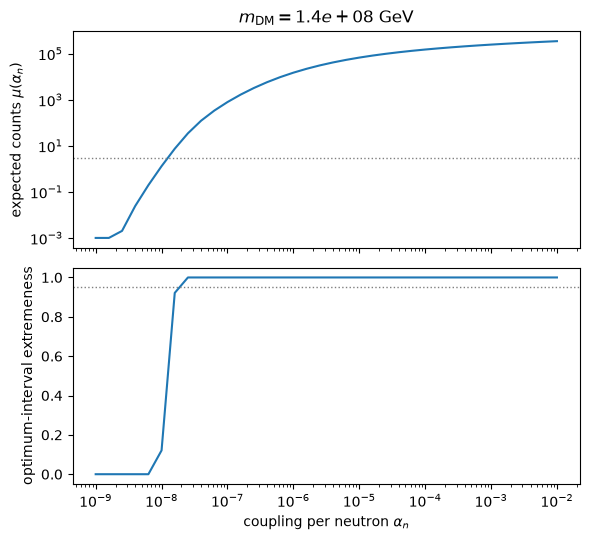

In [7]:
m_show = masses[3]
ps, mus = [], []
for a in alpha_scan:
    out = extremeness(a, m_show)
    p, mu = out if out is not None else (0.0, 0.0)
    ps.append(p)
    mus.append(mu)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5.5), sharex=True)
ax1.loglog(alpha_scan, np.maximum(mus, 1e-3), "-", color="#1f77b4")
ax1.axhline(3.0, color="#7f7f7f", lw=1, ls=":")
ax1.set_ylabel(r"expected counts $\mu(\alpha_n)$")
ax1.set_title(rf"$m_{{\rm DM}} = {m_show:.1e}$ GeV")
ax2.semilogx(alpha_scan, ps, "-", color="#1f77b4")
ax2.axhline(CONFIDENCE, color="#7f7f7f", lw=1, ls=":")
ax2.set_ylabel("optimum-interval extremeness")
ax2.set_xlabel(r"coupling per neutron $\alpha_n$")
fig.tight_layout()

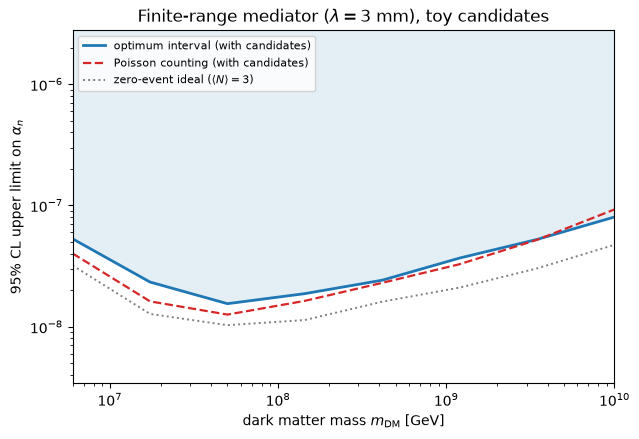

In [8]:
m_arr = np.array([r["m"] for r in results])
a_oi = np.array([r["a_oi"] for r in results])
a_pois = np.array([r["a_pois"] for r in results])
a_ideal = np.array([r["a_ideal"] for r in results])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
y_top = np.nanmax(a_pois) * 30
ax.fill_between(m_arr, a_oi, y_top, color="#1f77b4", alpha=0.12, lw=0)
ax.plot(
    m_arr, a_oi, "-", color="#1f77b4", lw=2, label="optimum interval (with candidates)"
)
ax.plot(
    m_arr,
    a_pois,
    "--",
    color="#d62728",
    lw=1.6,
    label="Poisson counting (with candidates)",
)
ax.plot(
    m_arr,
    a_ideal,
    ":",
    color="#7f7f7f",
    lw=1.4,
    label=r"zero-event ideal ($\langle N\rangle = 3$)",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(m_arr.min(), m_arr.max())
ax.set_ylim(np.nanmin(a_ideal) / 3, y_top)
ax.set_xlabel(r"dark matter mass $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"95% CL upper limit on $\alpha_n$")
ax.set_title(rf"Finite-range mediator ($\lambda = {LAMB * 1e3:.0f}$ mm), toy candidates")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("../figures/uhdm_finite_range_exclusion.png", dpi=140)

## Takeaways

- **The package scope stayed put.** All the mediator/halo physics lives in this
  notebook; the statistics went through three primitives
  (`generate` / `optimum_interval_statistic` / `extremeness_of_opt_itv_stat`)
  evaluated on a coupling grid. When your signal shape depends on the parameter
  you are limiting, this is the pattern.
- **The finite range creates a sensitivity floor** in coupling (the $\mu$ cliff),
  and the exclusion is an island in $(m_\text{DM}, \alpha_n)$ rather than the
  massless mediator's open region.
- **The optimum interval helps where there is room to be empty.** At low mass the
  support window is narrow and filled by the threshold cluster, so it tracks
  plain counting (paying a small calibration cost); at high mass the window
  extends past the outlier and the empty stretch wins.
- **Extensions** drop in as different inputs to the same pipeline: atmospheric
  attenuation replaces $f(v)$ with the slowed distribution at the detector
  (making the shape depend on $\alpha_n$ even more strongly — same grid handles
  it); $\lambda \to \infty$ recovers the massless-mediator tutorial.
- All parameters are fiducial; kicks are toys, not data.
